In [222]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import calendar
from scipy.stats import pearsonr


In [223]:
sns.color_palette('husl',10)

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.8616090647292522, 0.536495730113334, 0.19548899031476086),
 (0.6804189127793346, 0.6151497514677574, 0.19405452111445337),
 (0.46810256823426105, 0.6699492535792404, 0.1928958739904499),
 (0.20125317221201128, 0.6907920815379025, 0.47966761189275336),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 (0.2197995660828324, 0.6625157876850336, 0.7732093159317209),
 (0.433280341176423, 0.6065273407962815, 0.9585467098271748),
 (0.8004936186423958, 0.47703363533737203, 0.9579547196007522),
 (0.962272393509669, 0.3976451968965351, 0.8008274363432775)]

In [224]:
sns.set_style('darkgrid')
sns.set_palette('husl')

In [225]:
df = pd.read_csv('../datasets/global_hantavirus_surveillance_dataset_2026.csv', delimiter=',', encoding='utf-8')
df.head()

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


## Главные вопросы исследования:
- Кто в зоне риска? (возраст/пол/регион с самой высокой летальностью)

- Какие симптомы наиболее опасны? (корреляция с летальностью)

- Как зависит тяжесть от типа передачи? (Rodent-to-Human vs другие)

- Различаются ли штаммы по симптомам/летальности?

- Нужна ли госпитализация? (факторы, влияющие на hospital=1)

- Есть ли сезонность? (влияние report_date)

In [226]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                2000 non-null   str    
 1   country                2000 non-null   str    
 2   region                 2000 non-null   str    
 3   report_date            2000 non-null   str    
 4   virus_strain           2000 non-null   str    
 5   transmission_type      2000 non-null   str    
 6   exposure_source        2000 non-null   str    
 7   patient_age            2000 non-null   int64  
 8   gender                 2000 non-null   str    
 9   symptoms               2000 non-null   str    
 10  hospitalization        2000 non-null   str    
 11  fatality               2000 non-null   str    
 12  recovery_days          1845 non-null   float64
 13  temperature_celsius    2000 non-null   float64
 14  humidity_percent       2000 non-null   float64
 15  rodent_presence

сначала сделаем преобразование некоторых колонок для удобства подсчета

In [227]:
df['fatality'] = df['fatality'].map({'Yes':1, 'No':0}).astype('int64')

In [228]:
df['report_date'] = pd.to_datetime(df['report_date'], errors='coerce', dayfirst=True)

In [229]:
df['hospitalization'] = df['hospitalization'].map({'Yes':1, 'No':0}).astype('int64')

In [230]:
df['report_date'].value_counts()[df['report_date'].value_counts() >= 8].size / df['report_date'].nunique()

0.07142857142857142

данные имеют несколько (7% от общего числа) "пиковых" дней  с большим количеством случаев (от 8 до 12), а остальные дни - спорадические случаи

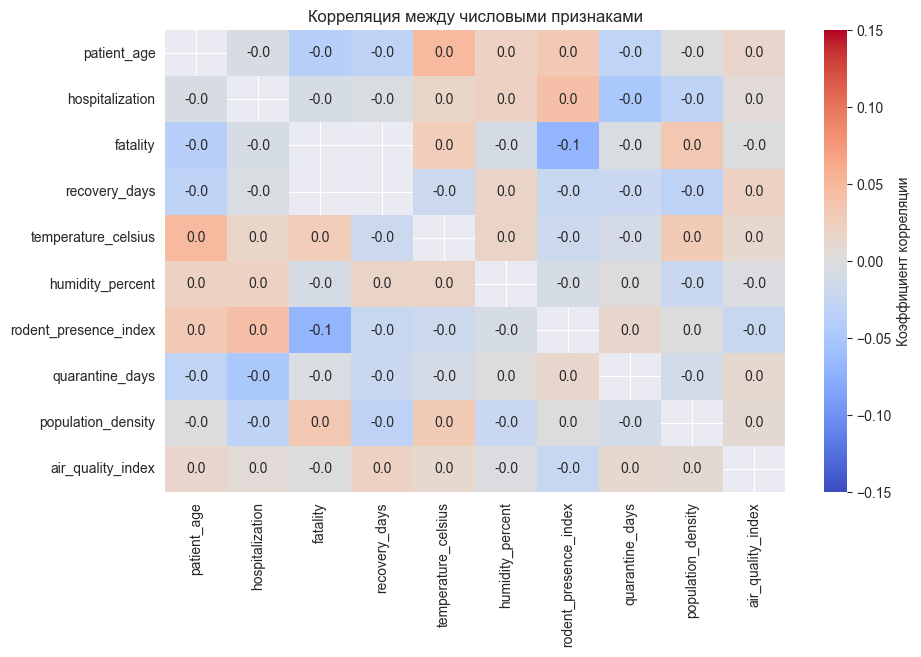

In [231]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
mask = np.eye(len(corr_matrix), dtype=bool)
sns.heatmap(corr_matrix, annot=True, center=0, fmt= '.1f', cmap='coolwarm', mask=mask, vmin=-0.15, vmax=0.15,
            cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Корреляция между числовыми признаками');

Сильной корреляции по Пирсону между числовыми признаками не наблюдается. Показатель recovery_days отсутствует для умерших (это 155 человек).

Сформулируем несколько гипотез и проверим их, подсчитав количество заболевших для каждого сценария.

| **Гипотеза**	| **Ожидаемая корреляция**  |
| ----------- | ----------- |
| Чем больше грызунов → тем больше случаев	| Положительная | 
| Высокая влажность → выше выживаемость вируса	| Положительная с cases  |
| Пожилой возраст → выше летальность	| Положительная с fatality  |
| Плотность населения → быстрее распространение	| Положительная с cases  |
| Высокая температура → вирус погибает	| Отрицательная с cases  |


In [232]:
country_status = (pd.crosstab(
    df['country'],
    df['rodent_presence_index'],
    normalize='index'
)*100).round(2)
country_status = country_status.round(2)
country_status

rodent_presence_index,1,2,3,4,5,6,7,8,9,10
country,,,,,,,,,,
Argentina,11.37,12.32,5.69,10.90,10.90,11.37,9.00,8.53,9.48,10.43
Bolivia,9.30,11.63,12.09,8.37,11.63,14.42,7.91,6.51,7.91,10.23
Brazil,8.21,8.21,9.18,13.04,16.43,10.14,9.18,10.14,7.73,7.73
Canada,8.65,10.10,7.69,9.62,8.17,5.77,11.06,15.38,12.02,11.54
Chile,9.47,11.58,11.05,10.00,8.42,9.47,10.53,10.53,10.00,8.95
Mexico,9.18,10.20,12.24,11.73,6.12,10.20,12.24,6.12,12.24,9.69
Paraguay,10.36,7.25,12.95,10.88,6.22,10.36,9.33,10.36,11.40,10.88
Peru,8.82,10.00,8.24,10.59,10.59,9.41,7.65,14.12,10.59,10.00
USA,9.62,9.62,10.10,11.54,9.13,5.77,16.35,8.17,11.06,8.65


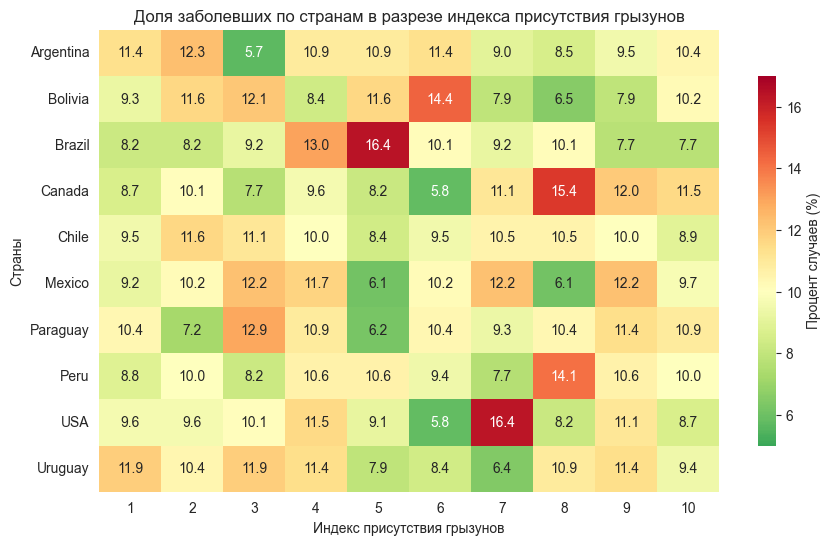

In [244]:
plt.figure(figsize=(10, 6))

sns.heatmap(country_status, annot=True, fmt='.1f', cmap='RdYlGn_r', center=10, vmin=5, vmax=17, linecolor='white',
            cbar_kws={'label': 'Процент случаев (%)', 'shrink': 0.8})
plt.title('Доля заболевших по странам в разрезе индекса присутствия грызунов')
plt.ylabel('Страны')
plt.xlabel('Индекс присутствия грызунов')

# plt.savefig('../visuals/....png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

In [256]:
pd.crosstab(
    [df['transmission_type'],
    df['exposure_source']],
    df['fatality'],
    values=df['case_id'],
    aggfunc='count',
    normalize='index'
)*100

fatality                                         0         1
transmission_type exposure_source                           
Human-to-Human    Agricultural Exposure  92.356688  7.643312
                  Cruise Exposure        93.582888  6.417112
                  Forest Exposure        90.298507  9.701493
                  Home Infestation       92.397661  7.602339
                  Rodent Exposure        92.857143  7.142857
                  Warehouse Exposure     91.919192  8.080808
Rodent-to-Human   Agricultural Exposure  94.039735  5.960265
                  Cruise Exposure        93.413174  6.586826
                  Forest Exposure        91.099476  8.900524
                  Home Infestation       91.875000  8.125000
                  Rodent Exposure        91.758242  8.241758
                  Warehouse Exposure     91.216216  8.783784

на графиках видно, что в зоне с самыми высокими (эпидемичными) уровнями присутствия грызунов самый низкий процент заболеваемости, а остальные типы распределились примерно одинаково, что говорит об отсутствии корреляции между индексом присутствия грызунов и заболеваемостью, что подтверждается статистическим тестом Пирсона

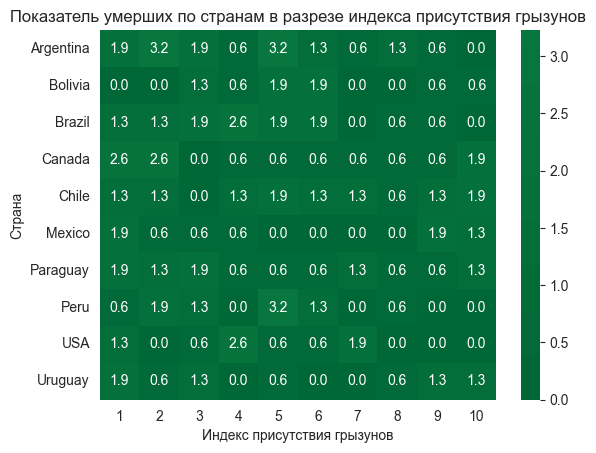

In [246]:
coutry_fatality = pd.crosstab(columns=df['rodent_presence_index'], index=df['country'],
                              values=df['fatality'], aggfunc='sum', normalize=True)*100
sns.heatmap(coutry_fatality,annot=True, fmt='.1f', cmap='RdYlGn_r', center=50)
plt.title('Показатель умерших по странам в разрезе индекса присутствия грызунов')
plt.xlabel('Индекс присутствия грызунов')
plt.ylabel('Страна');

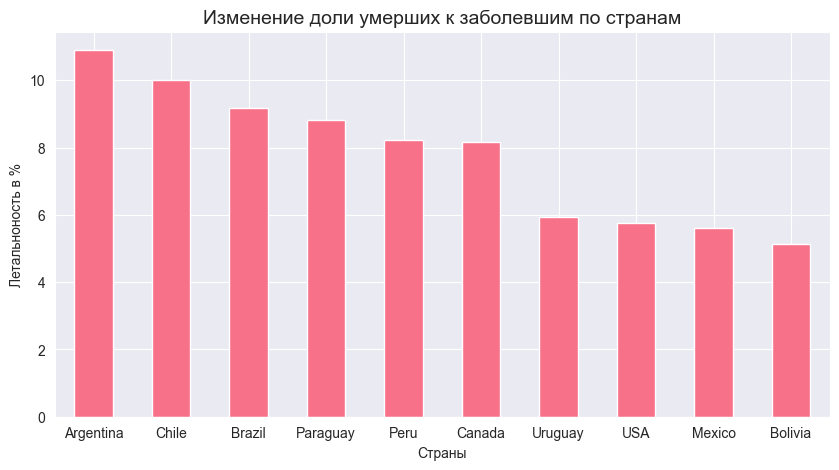

In [236]:
fatality_rate = (df.groupby('country')['fatality'].mean()*100).round(2).sort_values(ascending=False)
plt.figure(figsize=(10,5))
fatality_rate.plot(kind='bar')
plt.title('Изменение доли умерших к заболевшим по странам', fontsize=14)
plt.ylabel('Летальноность в %')
plt.xlabel('Страны')
plt.xticks(rotation=0)
plt.show()

Теперь посмотрим как менялось количество заболеваний в течение времени. Возьмем полный год - 2025

In [237]:
# df_2025 = df[df['report_date'].dt.year == 2025].copy()
months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
             'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
df['report_month'] = df['report_date'].dt.month.map(lambda x: months[x-1])
df['report_month'] = pd.Categorical(df['report_month'], categories=months, ordered=True)
df['report_month'].unique()

['Ноя', 'Апр', 'Мар', 'Фев', 'Дек', ..., 'Янв', 'Июл', 'Авг', 'Июн', 'Окт']
Length: 12
Categories (12, str): ['Янв' < 'Фев' < 'Мар' < 'Апр' ... 'Сен' < 'Окт' < 'Ноя' < 'Дек']

In [238]:
df['year'] = df['report_date'].dt.year

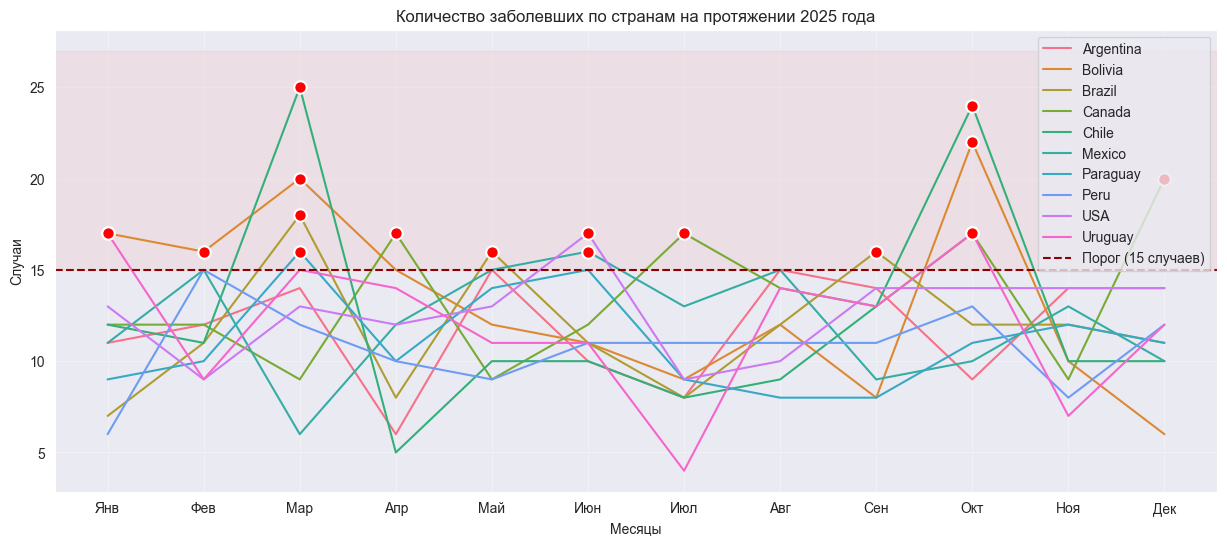

In [239]:
cases = df[df['year'] == 2025].groupby(['report_month','country']).size().reset_index(name='cases')
plt.figure(figsize=(15,6))
sns.lineplot(cases, x='report_month', y='cases', hue='country')
plt.title('Количество заболевших по странам на протяжении 2025 года')
plt.xlabel('Месяцы')
plt.ylabel('Случаи')
# Область выше порога
plt.axhspan(ymin=15, ymax=cases['cases'].max()+2, alpha=0.05, color='red')

# Линия порога
plt.axhline(y=15, color='darkred', linestyle='--', linewidth=1.5, label='Порог (15 случаев)')

# Точки превышения
high_points = cases[cases['cases'] > 15]
plt.scatter(high_points['report_month'], high_points['cases'],
            color='red', s=80, edgecolors='white', linewidth=1.5, zorder=5)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

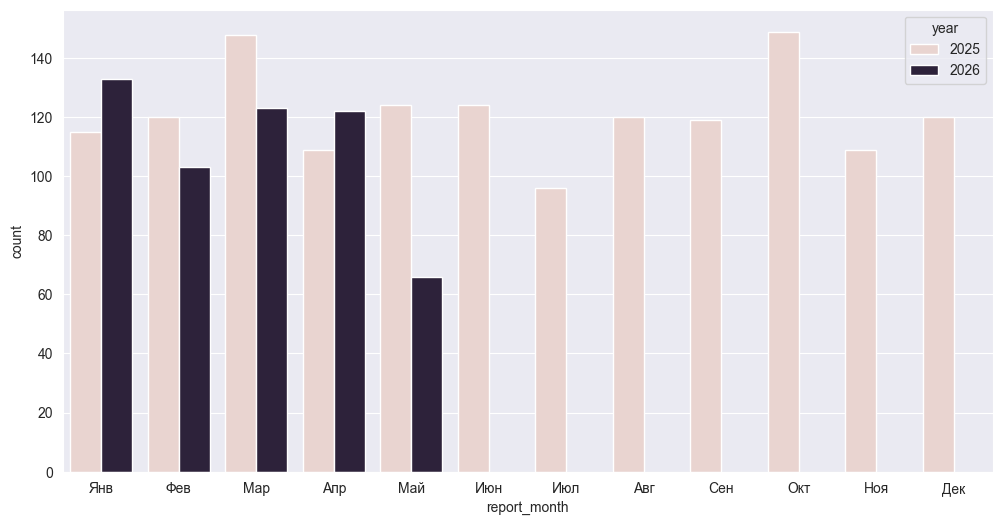

In [240]:

plt.figure(figsize=(12,6))
sns.countplot(x='report_month', data=df, hue='year')
plt.show()

В 2025м году было два небольших всплеска активности в марте и октябре, однако в 2026 эта тенденция не продолжается (пока), поэтому говорить о сезонности на основании этих данных не приходится

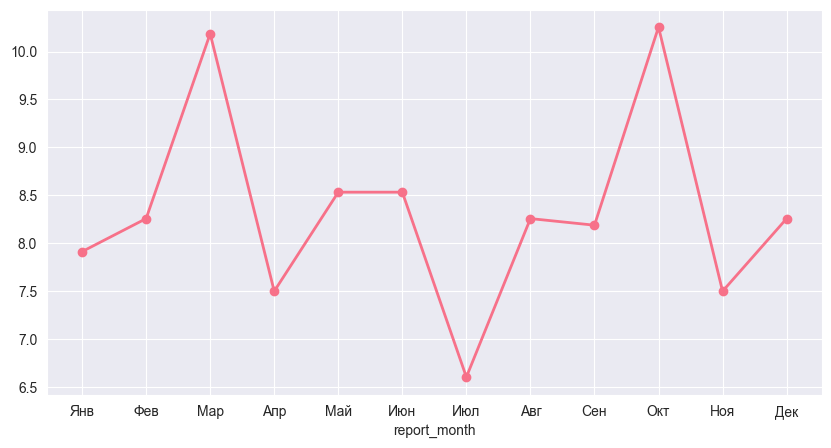

In [241]:
sick_graph = df[df['year']==2025]['report_month'].value_counts(normalize=True).sort_index() * 100
plt.figure(figsize=(10,5))
sick_graph.plot(kind='line', marker='o', linestyle='-', linewidth=2)
plt.xticks(labels=sick_graph.index, ticks=range(sick_graph.size), rotation=0)
plt.show()

In [242]:
# df['recovery_days'] = pd.qcut(df['recovery_days'], 6)
df['exposure_source'].value_counts(normalize=True) * 100

exposure_source
Cruise Exposure          17.70
Warehouse Exposure       17.30
Rodent Exposure          16.80
Home Infestation         16.55
Forest Exposure          16.25
Agricultural Exposure    15.40
Name: proportion, dtype: float64

In [243]:
df.columns

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index',
       'report_month', 'year'],
      dtype='str')